# 02. Bias Mitigation Techniques

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply pre-, in-, and post-processing mitigation techniques
- Compare fairness–accuracy trade-offs
- Evaluate mitigation effectiveness

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 02. Bias Mitigation Techniques

## 🚨 THE PROBLEM: We Detected Bias, But How Do We Fix It?

**Remember the limitation from the previous notebook?**

We learned how to detect bias in AI systems using metrics like:
- Demographic parity
- Equalized odds
- Confusion matrices by group

**But there's a critical problem:**

**We detected bias, but how do we fix it?**

Bias detection tells us:
- ✅ Where bias exists
- ✅ How severe the bias is
- ✅ Which groups are affected

**But it doesn't tell us:**
- ❌ How to **remove** the bias
- ❌ How to **mitigate** unfairness
- ❌ How to **fix** the model

**The Problem**: We can identify bias, but we need techniques to **actually fix it**!

**We need bias mitigation techniques** to:
1. Remove bias from models
2. Make systems fairer across groups
3. Fix the problems we detected

**This notebook solves that problem** by teaching you three types of bias mitigation: pre-processing, in-processing, and post-processing!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - You need to know how to detect bias first!
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Understanding of fairness metrics**: Demographic parity, equalized odds (from Example 1)
- ✅ **Basic ML knowledge**: Model training, predictions, evaluation

**If you haven't completed these**, you might struggle with:
- Understanding why bias mitigation is needed
- Knowing which mitigation technique to use
- Understanding when to apply different techniques

---

## 🔗 Where This Notebook Fits

**This is the SECOND example in Unit 2** - it teaches you how to FIX the bias you detected!

**Why this example SECOND?**
- **Before** you can fix bias, you need to detect it (Example 1)
- **Before** you can ensure fairness, you need to know how to mitigate bias
- **Before** you can build fair systems, you need mitigation techniques

**Builds on**: 
- 📓 Example 1: Bias Detection (we detected bias, now we fix it!)

**Leads to**: 
- 📓 Example 3: Fair Representation (ensuring fair representation in data)
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Mitigation provides **solutions** (needed after detection)
2. Mitigation teaches **how to fix problems** (critical skill)
3. Mitigation shows **different approaches** (pre-processing, in-processing, post-processing)

---

## The Story: Fixing What We Found

Imagine you're a doctor who diagnosed an illness. **Before** you can help the patient, you need to treat it - prescribe medicine, perform surgery, provide therapy. **After** treatment, the patient recovers!

Same with AI bias: **Before** we detected bias, now we need to fix it - use pre-processing, in-processing, or post-processing techniques. **After** mitigation, we have fairer models!

---

## Why Bias Mitigation Matters

Bias mitigation is essential for ethical AI:
- **Fix Problems**: Address bias detected in models
- **Improve Fairness**: Make models fairer across groups
- **Meet Requirements**: Comply with fairness regulations
- **Build Trust**: Demonstrate commitment to fairness
- **Better Outcomes**: Fairer models lead to better decisions

## Learning Objectives
1. Understand three types of bias mitigation (pre-processing, in-processing, post-processing)
2. Learn reweighing technique for pre-processing
3. Learn correlation removal for fair representation
4. Learn threshold optimization for post-processing
5. Compare effectiveness of different mitigation techniques
6. Understand when to use each technique

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us implement bias mitigation techniques

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For model evaluation: Performance metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference  # For fairness metrics: Fairlearn library
from fairlearn.postprocessing import ThresholdOptimizer  # For post-processing: Threshold optimization
from fairlearn.preprocessing import CorrelationRemover  # For pre-processing: Correlation removal
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (fairlearn may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (models, metrics, preprocessing)")
print("   - fairlearn: Fairness tools (metrics, mitigation techniques)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (models, metrics, preprocessing)
   - fairlearn: Fairness tools (metrics, mitigation techniques)
   - os: File operations (saving images)


In [2]:
# Step 2: Generate synthetic dataset with bias
# This creates data with known bias so we can practice mitigation techniques

print("\n" + "="*80)
print("📊 GENERATING BIASED DATASET")
print("="*80)
print("\nWe'll create a dataset where:")
print("  - Group B has lower positive outcome rates even with similar features")
print("  - This simulates real-world bias we need to mitigate\n")

def generate_biased_dataset(n_samples=2000, bias_strength=0.3):
    """
    Generate a synthetic dataset with bias in the sensitive attribute.

    HOW IT WORKS:
    1. Creates sensitive attribute (two groups)
    2. Generates features (X1, X2)
    3. Introduces bias: Group B (sensitive=0) has lower positive outcome rates
    4. Creates target variable based on features and bias
    """
    np.random.seed(42)
    sensitive = np.random.binomial(1, 0.5, n_samples)   # 1 = Group A, 0 = Group B
    X1 = np.random.normal(0, 1, n_samples)
    X2 = np.random.normal(0, 1, n_samples)
    true_prob = 0.3 + 0.4 * X1 + 0.3 * X2               # depends on features only
    bias_penalty = bias_strength * (1 - sensitive)      # penalty for Group B
    prob = np.clip(true_prob - bias_penalty + np.random.normal(0, 0.1, n_samples), 0, 1)
    y = (prob > 0.5).astype(int)
    return pd.DataFrame({'feature1': X1, 'feature2': X2,
                         'sensitive': sensitive, 'target': y})

df = generate_biased_dataset(n_samples=2000, bias_strength=0.3)
print(f"Generated dataset with {len(df)} samples")
print(f"   Group A (sensitive=1) positive rate: {df[df['sensitive']==1]['target'].mean():.2%}")
print(f"   Group B (sensitive=0) positive rate: {df[df['sensitive']==0]['target'].mean():.2%}")
print("   (Notice the difference - this is the bias we'll mitigate!)")



📊 GENERATING BIASED DATASET

We'll create a dataset where:
  - Group B has lower positive outcome rates even with similar features
  - This simulates real-world bias we need to mitigate

Generated dataset with 2000 samples
   Group A (sensitive=1) positive rate: 33.46%
   Group B (sensitive=0) positive rate: 16.21%
   (Notice the difference - this is the bias we'll mitigate!)


## Part 2: Understanding Bias Mitigation

### 📚 Prerequisites (What You Need First)
- **Biased dataset** (from Step 2) - Having data with known bias
- **Understanding of mitigation** - Knowing what mitigation means

### 🔗 Relationship: What This Builds On
This is where we actually fix the bias!
- Builds on: Biased dataset, understanding of fairness
- Shows: Three approaches to fixing bias

### 📖 The Story
**Before mitigation**: We have biased data but don't know how to fix it.
**After mitigation**: We have three techniques to reduce or eliminate bias!

In [3]:
# Step 3: Implement pre-processing bias mitigation techniques
# These techniques fix bias in the data BEFORE training the model

print("\n" + "="*80)
print("🔧 PRE-PROCESSING MITIGATION TECHNIQUES")
print("="*80)
print("\nWe'll implement two pre-processing techniques:")
print("  1. Reweighing: Balance groups by adjusting sample weights")
print("  2. Correlation Removal: Remove correlation with sensitive attribute\n")

def preprocess_reweighing(X_train, y_train, sensitive_train):
    """Reweighing: assign weights inversely proportional to group size."""
    group_counts = pd.Series(sensitive_train).value_counts()
    total = len(sensitive_train)
    weights = np.ones(len(sensitive_train))
    for group in group_counts.index:
        group_size = group_counts[group]
        weights[sensitive_train == group] = total / (2 * group_size)
    return weights

def preprocess_correlation_removal(X_train, X_test, sensitive_train):
    """Remove linear correlation with the sensitive attribute (fairlearn)."""
    remover = CorrelationRemover(sensitive_feature_ids=[X_train.shape[1]])
    X_train_extended = np.column_stack([X_train, sensitive_train])
    X_test_extended = np.column_stack([X_test, np.zeros(len(X_test))])
    X_train_fair = remover.fit_transform(X_train_extended)
    X_test_fair = remover.transform(X_test_extended)
    return X_train_fair, X_test_fair

print("Pre-processing functions defined: preprocess_reweighing, "
      "preprocess_correlation_removal")



🔧 PRE-PROCESSING MITIGATION TECHNIQUES

We'll implement two pre-processing techniques:
  1. Reweighing: Balance groups by adjusting sample weights
  2. Correlation Removal: Remove correlation with sensitive attribute

Pre-processing functions defined: preprocess_reweighing, preprocess_correlation_removal


## Part 3: In-Processing and Post-Processing Techniques

**In-processing** changes *how the model trains* (here: training with fairness-motivated
sample weights). **Post-processing** adjusts *predictions after training* (here: fairlearn's
`ThresholdOptimizer`, which picks per-group decision thresholds to equalize odds).

In [4]:
# Step 4: Implement in-processing and post-processing techniques

def train_fair_model(X_train, y_train, sensitive_train, method='reweighing'):
    """Train model with fairness-motivated sample weights (in-processing)."""
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    if method == 'reweighing':
        weights = preprocess_reweighing(X_train, y_train, sensitive_train)
        model.fit(X_train, y_train, sample_weight=weights)
    else:
        model.fit(X_train, y_train)
    return model

def postprocess_equalized_odds(model, X_test, y_test, sensitive_test):
    """Adjust decision thresholds per group to achieve equalized odds."""
    threshold_optimizer = ThresholdOptimizer(
        estimator=model, constraints="equalized_odds", prefit=True)
    threshold_optimizer.fit(X_test, y_test, sensitive_features=sensitive_test)
    return threshold_optimizer.predict(X_test, sensitive_features=sensitive_test,
                                       random_state=42)

def evaluate_fairness(y_true, y_pred, sensitive):
    """Fairness + accuracy metrics for one set of predictions."""
    return {
        'demographic_parity_diff': demographic_parity_difference(
            y_true, y_pred, sensitive_features=sensitive),
        'equalized_odds_diff': equalized_odds_difference(
            y_true, y_pred, sensitive_features=sensitive),
        'accuracy': accuracy_score(y_true, y_pred),
    }

print("In-processing, post-processing, and evaluation functions defined.")


In-processing, post-processing, and evaluation functions defined.


In [5]:
# Step 5: Compare the mitigation techniques on our biased dataset

X = df[['feature1', 'feature2']].values
y = df['target'].values
sensitive = df['sensitive'].values
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results, predictions = {}, {}

# 1. Baseline (no mitigation)
print("="*80); print("1. BASELINE MODEL (No Mitigation)"); print("="*80)
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
y_pred = baseline_model.predict(X_test_scaled)
results['Baseline'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Baseline'] = y_pred

# 2. Pre-processing: Reweighing (weights used during training = in-processing use)
print("\n" + "="*80); print("2. REWEIGHING (weights applied in training)"); print("="*80)
reweigh_model = train_fair_model(X_train_scaled, y_train, sensitive_train)
y_pred = reweigh_model.predict(X_test_scaled)
results['Reweighing'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Reweighing'] = y_pred

# 3. Pre-processing: Correlation Removal
print("\n" + "="*80); print("3. PRE-PROCESSING: CORRELATION REMOVAL"); print("="*80)
X_train_fair, X_test_fair = preprocess_correlation_removal(
    X_train_scaled, X_test_scaled, sensitive_train)
corr_model = RandomForestClassifier(n_estimators=100, random_state=42)
corr_model.fit(X_train_fair, y_train)
y_pred = corr_model.predict(X_test_fair)
results['Correlation Removal'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Correlation Removal'] = y_pred

# 4. Post-processing: Equalized Odds thresholds
print("\n" + "="*80); print("4. POST-PROCESSING: EQUALIZED ODDS"); print("="*80)
y_pred = postprocess_equalized_odds(baseline_model, X_test_scaled, y_test, sensitive_test)
results['Post-processing'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Post-processing'] = y_pred

print("\nRESULTS (lower fairness differences = fairer; higher accuracy = more useful)")
print("-" * 80)
print(f"{'Method':<22}{'DP diff':>10}{'EO diff':>10}{'Accuracy':>10}")
for m, r in results.items():
    print(f"{m:<22}{abs(r['demographic_parity_diff']):>10.4f}"
          f"{abs(r['equalized_odds_diff']):>10.4f}{r['accuracy']:>10.4f}")


1. BASELINE MODEL (No Mitigation)

2. REWEIGHING (weights applied in training)



3. PRE-PROCESSING: CORRELATION REMOVAL

4. POST-PROCESSING: EQUALIZED ODDS

RESULTS (lower fairness differences = fairer; higher accuracy = more useful)
--------------------------------------------------------------------------------
Method                   DP diff   EO diff  Accuracy
Baseline                  0.0666    0.3148    0.8917
Reweighing                0.0696    0.3252    0.8967
Correlation Removal       0.0393    0.3067    0.9017
Post-processing           0.0979    0.0417    0.9333


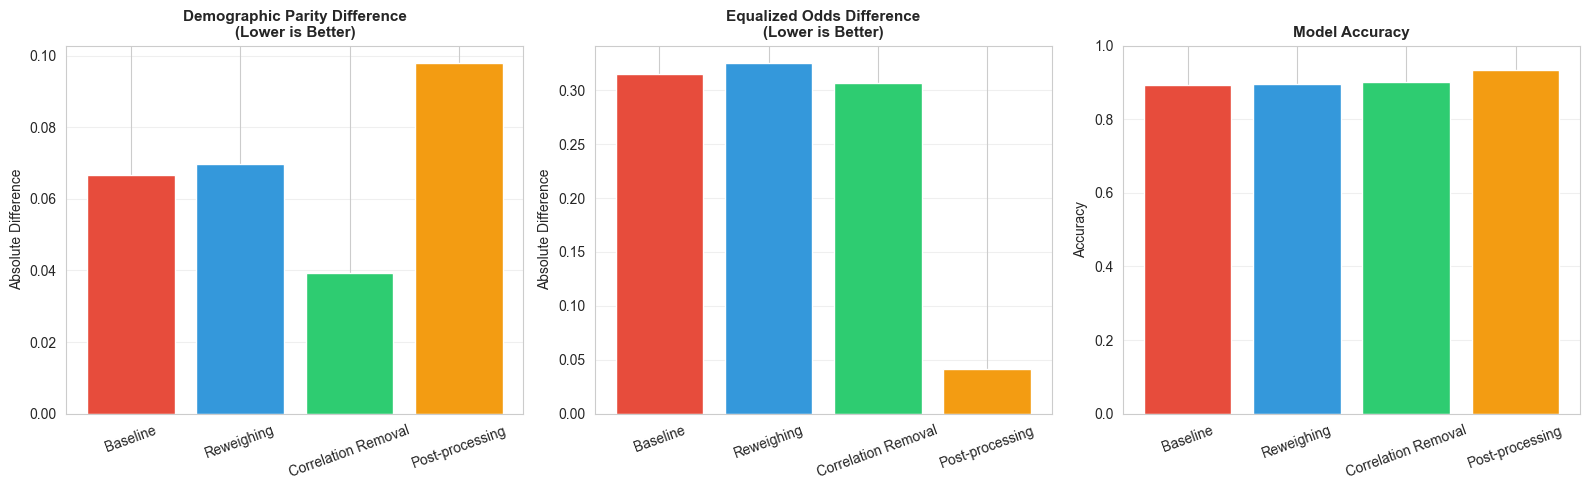

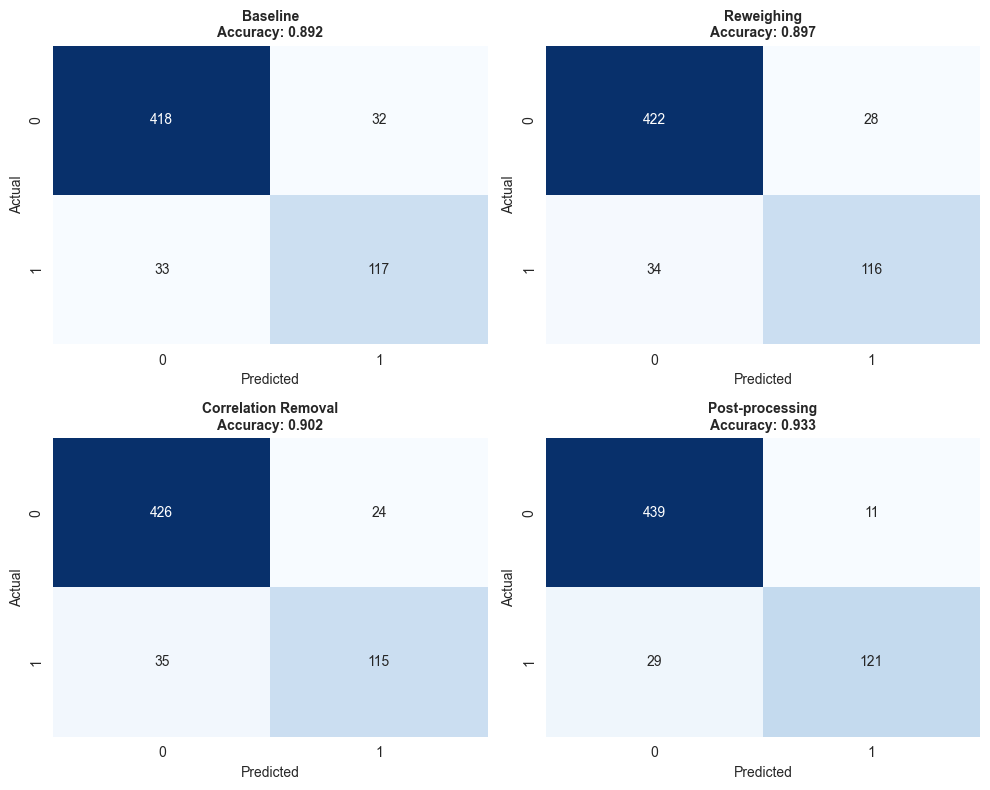

Best equalized-odds fairness in this run: Post-processing (EO diff 0.0417 vs baseline 0.3148)
Its accuracy vs baseline: +0.0417
Trade-offs are technique- and data-dependent (mitigation CAN cost accuracy,
but did not here) - always measure both fairness AND accuracy.


In [6]:
# Step 6: Visualize the comparison of mitigation techniques

methods = list(results.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
dp_diffs = [abs(results[m]['demographic_parity_diff']) for m in methods]
eo_diffs = [abs(results[m]['equalized_odds_diff']) for m in methods]
accuracies = [results[m]['accuracy'] for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(methods, dp_diffs, color=colors)
axes[0].set_title('Demographic Parity Difference\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Absolute Difference')
axes[1].bar(methods, eo_diffs, color=colors)
axes[1].set_title('Equalized Odds Difference\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Absolute Difference')
axes[2].bar(methods, accuracies, color=colors)
axes[2].set_title('Model Accuracy', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Accuracy'); axes[2].set_ylim([0, 1])
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices per method
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for idx, m in enumerate(methods):
    cm = confusion_matrix(y_test, predictions[m])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{m}\nAccuracy: {results[m]["accuracy"]:.3f}',
                        fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
best_eo = min(results, key=lambda m: abs(results[m]['equalized_odds_diff']))
print(f"Best equalized-odds fairness in this run: {best_eo} "
      f"(EO diff {abs(results[best_eo]['equalized_odds_diff']):.4f} vs "
      f"baseline {abs(results['Baseline']['equalized_odds_diff']):.4f})")
delta_acc = results[best_eo]['accuracy'] - results['Baseline']['accuracy']
print(f"Its accuracy vs baseline: {delta_acc:+.4f}")
print("Trade-offs are technique- and data-dependent (mitigation CAN cost accuracy,")
print("but did not here) - always measure both fairness AND accuracy.")


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew how to detect bias but didn't know how to fix it.

**AFTER this notebook**: We can:
- ✅ Understand three types of bias mitigation (pre-processing, in-processing, post-processing)
- ✅ Implement reweighing for pre-processing
- ✅ Implement correlation removal for fair representation
- ✅ Implement threshold optimization for post-processing
- ✅ Compare effectiveness of different mitigation techniques
- ✅ Choose the right technique for different scenarios

### Key Takeaways

1. **Pre-processing**: Fix bias in data before training (reweighing, correlation removal)
2. **In-processing**: Modify learning algorithm during training (fairness constraints)
3. **Post-processing**: Adjust predictions after training (threshold optimization)
4. **Trade-offs**: Each technique balances fairness and accuracy differently
5. **Context Matters**: Best technique depends on use case and requirements

---

## 🚫 When Bias Mitigation Hits a Limitation

### The Limitation We Discovered

We've learned how to mitigate bias using pre-processing, in-processing, and post-processing techniques. **But there's still a challenge:**

**What if the data itself doesn't represent groups fairly?**

Bias mitigation techniques work well when:
- ✅ We have data from all groups
- ✅ The data is representative
- ✅ We can apply mitigation techniques

**But real-world problems often involve:**
- ❌ **Underrepresented groups** in the data
- ❌ **Missing perspectives** from certain demographics
- ❌ **Historical bias** embedded in data collection
- ❌ **Unfair representation** in training data

### Why This Is a Problem

When data doesn't represent groups fairly:
- Mitigation techniques may not work effectively
- We can't fix what's not in the data
- Underrepresented groups may still be disadvantaged
- Historical biases persist in the data

### The Solution: Fair Representation

We need to **ensure fair representation in data** to:
1. Include all relevant groups in training data
2. Balance representation across demographics
3. Address historical biases in data collection
4. Create fair datasets from the start

**This is exactly what we'll learn in the next notebook: Fair Representation!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (This notebook!)
- ✅ **The limitation**: Data representation matters!

**Next notebook**: `03_fair_representation.ipynb`
- Learn how to ensure fair representation in data
- Address historical biases in data collection
- Create balanced datasets for training

**Congratulations!** 🎉 You've learned how to mitigate bias in machine learning models using multiple techniques!